In [1]:
import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

physical_gpus = tf.config.list_physical_devices("GPU")

for gpu in physical_gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

strategy = tf.distribute.MirroredStrategy()

print("TensorFlow version:", tf.__version__)
print("Physical GPUs detected:", physical_gpus)
print("GPUs in use:", strategy.num_replicas_in_sync)

print("\nExperiment: ResNet50 Feature-Level SMOTE")
print("Feature extractor: Frozen pretrained ResNet50")
print("Embedding size: 2048")
print("SMOTE k-neighbours: 5")
print("Dropout: Disabled")
print("Focal loss: Disabled")
print("Class weights: Disabled")
print("Balanced batches: Disabled")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.20.0
Physical GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPUs in use: 2

Experiment: ResNet50 Feature-Level SMOTE
Feature extractor: Frozen pretrained ResNet50
Embedding size: 2048
SMOTE k-neighbours: 5
Dropout: Disabled
Focal loss: Disabled
Class weights: Disabled
Balanced batches: Disabled


I0000 00:00:1789447581.254635      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789447581.257697      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
dataset_path = kagglehub.dataset_download(
    "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
)

image_root = Path(dataset_path) / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_mapping.items():
    class_folder = image_root / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
IMG_SIZE = (224, 224)
EXTRACTION_BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_original_image(filepath):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image

def create_feature_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices(
        dataframe["filepath"].values
    )

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(EXTRACTION_BATCH_SIZE)
    return dataset.prefetch(AUTOTUNE)

train_image_dataset = create_feature_dataset(train_df)
validation_image_dataset = create_feature_dataset(validation_df)
test_image_dataset = create_feature_dataset(test_df)

print("Extraction batch size:", EXTRACTION_BATCH_SIZE)
print("Training batches:", len(train_image_dataset))
print("Validation batches:", len(validation_image_dataset))
print("Test batches:", len(test_image_dataset))

Extraction batch size: 64
Training batches: 482
Validation batches: 104
Test batches: 104


In [7]:
with strategy.scope():
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))

    x = tf.keras.applications.resnet50.preprocess_input(inputs)

    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    embeddings = tf.keras.layers.GlobalAveragePooling2D(
        name="feature_embedding"
    )(x)

    feature_extractor = tf.keras.Model(
        inputs,
        embeddings,
        name="ResNet50_Feature_Extractor"
    )

print("GPUs in use:", strategy.num_replicas_in_sync)
print("Feature shape:", feature_extractor.output_shape)
print("Trainable parameters:", len(feature_extractor.trainable_weights))
print("ResNet50 frozen:", not base_model.trainable)

feature_extractor.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
GPUs in use: 2
Feature shape: (None, 2048)
Trainable parameters: 0
ResNet50 frozen: True


Model: "ResNet50_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_embedding   │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
print("Extracting training embeddings...")
train_features = feature_extractor.predict(
    train_image_dataset,
    verbose=1
).astype(np.float32)

print("\nExtracting validation embeddings...")
validation_features = feature_extractor.predict(
    validation_image_dataset,
    verbose=1
).astype(np.float32)

print("\nExtracting test embeddings...")
test_features = feature_extractor.predict(
    test_image_dataset,
    verbose=1
).astype(np.float32)

train_labels = train_df["label"].to_numpy(dtype=np.int32)
validation_labels = validation_df["label"].to_numpy(dtype=np.int32)
test_labels = test_df["label"].to_numpy(dtype=np.int32)

print("\nTraining feature shape:", train_features.shape)
print("Validation feature shape:", validation_features.shape)
print("Test feature shape:", test_features.shape)

print("Training labels:", train_labels.shape)
print("NaN values:", np.isnan(train_features).sum())
print("Infinite values:", np.isinf(train_features).sum())

np.save(
    "/kaggle/working/train_resnet50_features.npy",
    train_features
)
np.save(
    "/kaggle/working/validation_resnet50_features.npy",
    validation_features
)
np.save(
    "/kaggle/working/test_resnet50_features.npy",
    test_features
)

print("Embeddings extracted and saved.")

Extracting training embeddings...
482/482 ━━━━━━━━━━━━━━━━━━━━ 83s 160ms/step

Extracting validation embeddings...
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step

Extracting test embeddings...
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step

Training feature shape: (30800, 2048)
Validation feature shape: (6600, 2048)
Test feature shape: (6600, 2048)
Training labels: (30800,)
NaN values: 0
Infinite values: 0
Embeddings extracted and saved.


In [9]:
from sklearn.preprocessing import StandardScaler
import joblib

feature_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(
    train_features
).astype(np.float32)

validation_features_scaled = feature_scaler.transform(
    validation_features
).astype(np.float32)

test_features_scaled = feature_scaler.transform(
    test_features
).astype(np.float32)

print("Scaled training shape:", train_features_scaled.shape)
print("Scaled validation shape:", validation_features_scaled.shape)
print("Scaled test shape:", test_features_scaled.shape)

print(
    "Training feature mean:",
    round(float(train_features_scaled.mean()), 4)
)
print(
    "Training feature standard deviation:",
    round(float(train_features_scaled.std()), 4)
)

print("NaN values:", np.isnan(train_features_scaled).sum())
print("Infinite values:", np.isinf(train_features_scaled).sum())

joblib.dump(
    feature_scaler,
    "/kaggle/working/resnet50_feature_scaler.joblib"
)

print("Feature scaler saved.")

Scaled training shape: (30800, 2048)
Scaled validation shape: (6600, 2048)
Scaled test shape: (6600, 2048)
Training feature mean: 0.0
Training feature standard deviation: 1.0
NaN values: 0
Infinite values: 0
Feature scaler saved.


In [10]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(train_labels))

smote = SMOTE(
    sampling_strategy="auto",
    random_state=SEED,
    k_neighbors=5
)

smote_train_features, smote_train_labels = smote.fit_resample(
    train_features_scaled,
    train_labels
)

smote_train_features = smote_train_features.astype(np.float32)
smote_train_labels = smote_train_labels.astype(np.int32)

original_training_count = len(train_features_scaled)
synthetic_count = (
    len(smote_train_features) - original_training_count
)

print("After SMOTE:", Counter(smote_train_labels))
print("Original training embeddings:", original_training_count)
print("Synthetic embeddings created:", synthetic_count)
print("Final training embeddings:", len(smote_train_features))
print("Final feature shape:", smote_train_features.shape)

print("NaN values:", np.isnan(smote_train_features).sum())
print("Infinite values:", np.isinf(smote_train_features).sum())

Before SMOTE: Counter({np.int32(1): 21840, np.int32(0): 8960})
After SMOTE: Counter({np.int32(1): 21840, np.int32(0): 21840})
Original training embeddings: 30800
Synthetic embeddings created: 12880
Final training embeddings: 43680
Final feature shape: (43680, 2048)
NaN values: 0
Infinite values: 0


In [11]:
synthetic_features = smote_train_features[
    original_training_count:
]

synthetic_labels = smote_train_labels[
    original_training_count:
]

original_minority_features = train_features_scaled[
    train_labels == 0
]

print("Synthetic feature shape:", synthetic_features.shape)
print(
    "Synthetic label counts:",
    Counter(synthetic_labels)
)

print(
    "Original embeddings preserved:",
    np.allclose(
        smote_train_features[:original_training_count],
        train_features_scaled
    )
)

print(
    "Synthetic features are finite:",
    np.isfinite(synthetic_features).all()
)

minority_min = original_minority_features.min(axis=0)
minority_max = original_minority_features.max(axis=0)

within_minority_range = np.all(
    (synthetic_features >= minority_min - 1e-6) &
    (synthetic_features <= minority_max + 1e-6)
)

print(
    "Synthetic features within minority feature ranges:",
    within_minority_range
)

assert synthetic_features.shape == (12880, 2048)
assert np.all(synthetic_labels == 0)

print("Basic SMOTE sanity checks passed.")

Synthetic feature shape: (12880, 2048)
Synthetic label counts: Counter({np.int32(0): 12880})
Original embeddings preserved: True
Synthetic features are finite: True
Synthetic features within minority feature ranges: True
Basic SMOTE sanity checks passed.


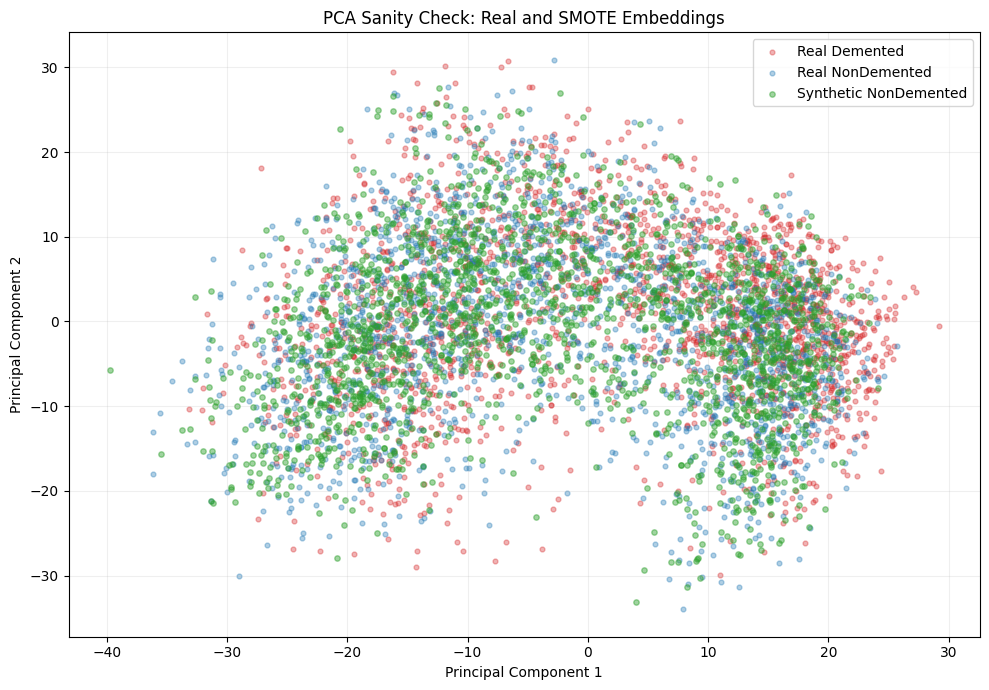

Variance represented by two components: 0.1587


In [12]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(SEED)
SAMPLES_PER_GROUP = 2000

real_class_0 = train_features_scaled[train_labels == 0]
real_class_1 = train_features_scaled[train_labels == 1]

class_0_indices = rng.choice(
    len(real_class_0),
    size=min(SAMPLES_PER_GROUP, len(real_class_0)),
    replace=False
)

class_1_indices = rng.choice(
    len(real_class_1),
    size=min(SAMPLES_PER_GROUP, len(real_class_1)),
    replace=False
)

synthetic_indices = rng.choice(
    len(synthetic_features),
    size=min(SAMPLES_PER_GROUP, len(synthetic_features)),
    replace=False
)

pca = PCA(
    n_components=2,
    svd_solver="randomized",
    random_state=SEED
)

# Fit PCA only on real training embeddings
pca.fit(train_features_scaled)

real_0_pca = pca.transform(
    real_class_0[class_0_indices]
)

real_1_pca = pca.transform(
    real_class_1[class_1_indices]
)

synthetic_pca = pca.transform(
    synthetic_features[synthetic_indices]
)

plt.figure(figsize=(10, 7))

plt.scatter(
    real_1_pca[:, 0],
    real_1_pca[:, 1],
    s=12,
    alpha=0.35,
    label="Real Demented",
    color="tab:red"
)

plt.scatter(
    real_0_pca[:, 0],
    real_0_pca[:, 1],
    s=12,
    alpha=0.35,
    label="Real NonDemented",
    color="tab:blue"
)

plt.scatter(
    synthetic_pca[:, 0],
    synthetic_pca[:, 1],
    s=15,
    alpha=0.45,
    label="Synthetic NonDemented",
    color="tab:green"
)

plt.title("PCA Sanity Check: Real and SMOTE Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(
    "Variance represented by two components:",
    round(float(pca.explained_variance_ratio_.sum()), 4)
)

In [13]:
CLASSIFIER_BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_feature_dataset = tf.data.Dataset.from_tensor_slices((
    smote_train_features,
    smote_train_labels.astype(np.float32)
))

train_feature_dataset = train_feature_dataset.shuffle(
    buffer_size=len(smote_train_labels),
    seed=SEED,
    reshuffle_each_iteration=True
).batch(
    CLASSIFIER_BATCH_SIZE
).prefetch(AUTOTUNE)

validation_feature_dataset = tf.data.Dataset.from_tensor_slices((
    validation_features_scaled,
    validation_labels.astype(np.float32)
)).batch(
    CLASSIFIER_BATCH_SIZE
).prefetch(AUTOTUNE)

test_feature_dataset = tf.data.Dataset.from_tensor_slices((
    test_features_scaled,
    test_labels.astype(np.float32)
)).batch(
    CLASSIFIER_BATCH_SIZE
).prefetch(AUTOTUNE)

feature_batch, feature_label_batch = next(
    iter(train_feature_dataset)
)

print("Feature batch shape:", feature_batch.shape)
print("Label batch shape:", feature_label_batch.shape)

print(
    "NonDemented in first batch:",
    int(tf.reduce_sum(
        tf.cast(feature_label_batch == 0, tf.int32)
    ))
)

print(
    "Demented in first batch:",
    int(tf.reduce_sum(
        tf.cast(feature_label_batch == 1, tf.int32)
    ))
)

print("Training batches:", len(train_feature_dataset))
print("Validation batches:", len(validation_feature_dataset))
print("Test batches:", len(test_feature_dataset))

Feature batch shape: (32, 2048)
Label batch shape: (32,)
NonDemented in first batch: 16
Demented in first batch: 16
Training batches: 1365
Validation batches: 207
Test batches: 207


In [14]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

print("Input features:", smote_train_features.shape[1])
print("Classifier batch size:", CLASSIFIER_BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)

print("Training embeddings:", len(smote_train_features))
print("Validation embeddings:", len(validation_features_scaled))
print("Test embeddings:", len(test_features_scaled))

print("Loss function: Binary Cross-Entropy")
print("Activation function: Sigmoid")
print("SMOTE: Enabled")
print("Dropout: Disabled")
print("Focal loss: Disabled")
print("Class weights: Disabled")
print("GPUs available to strategy:", strategy.num_replicas_in_sync)

Input features: 2048
Classifier batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Training embeddings: 43680
Validation embeddings: 6600
Test embeddings: 6600
Loss function: Binary Cross-Entropy
Activation function: Sigmoid
SMOTE: Enabled
Dropout: Disabled
Focal loss: Disabled
Class weights: Disabled
GPUs available to strategy: 2


In [15]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

with strategy.scope():
    classifier_inputs = tf.keras.Input(
        shape=(smote_train_features.shape[1],),
        name="resnet50_embedding"
    )

    classifier_outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="binary_classifier"
    )(classifier_inputs)

    classifier = tf.keras.Model(
        classifier_inputs,
        classifier_outputs,
        name="ResNet50_Feature_SMOTE_Classifier"
    )

    classifier.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

print("GPUs in use:", strategy.num_replicas_in_sync)
print("Total parameters:", classifier.count_params())
print("Trainable parameters:", classifier.count_params())

classifier.summary()

GPUs in use: 2
Total parameters: 2049
Trainable parameters: 2049


Model: "ResNet50_Feature_SMOTE_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50_embedding (InputLayer) │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_classifier (Dense)       │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_feature_smote_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks created.")

Callbacks created.


In [17]:
history = classifier.fit(
    train_feature_dataset,
    validation_data=validation_feature_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

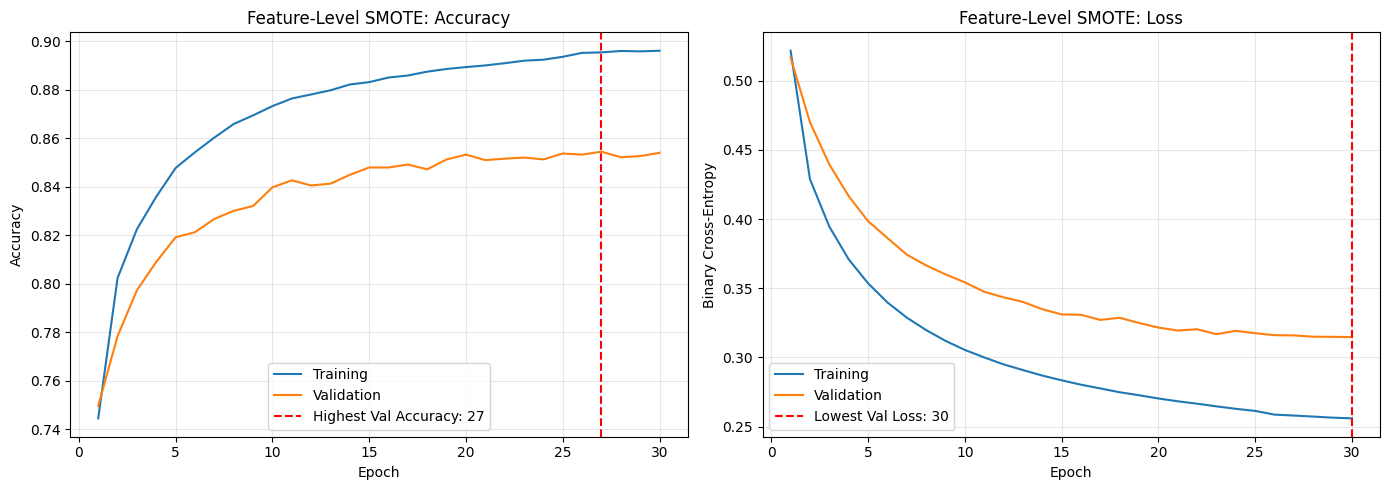

Best validation-loss epoch: 30
Best validation-accuracy epoch: 27


In [18]:
best_loss_epoch = np.argmin(history.history["val_loss"]) + 1
best_accuracy_epoch = np.argmax(history.history["val_accuracy"]) + 1
epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].axvline(
    best_accuracy_epoch,
    color="red",
    linestyle="--",
    label=f"Highest Val Accuracy: {best_accuracy_epoch}"
)
axes[0].set_title("Feature-Level SMOTE: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].axvline(
    best_loss_epoch,
    color="red",
    linestyle="--",
    label=f"Lowest Val Loss: {best_loss_epoch}"
)
axes[1].set_title("Feature-Level SMOTE: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best validation-loss epoch:", best_loss_epoch)
print("Best validation-accuracy epoch:", best_accuracy_epoch)

In [19]:
with strategy.scope():
    best_classifier = tf.keras.models.load_model(
        "/kaggle/working/resnet50_feature_smote_best.keras"
    )

print("Best feature-level SMOTE classifier loaded.")
print("Selected validation-loss epoch:", best_loss_epoch)

Best feature-level SMOTE classifier loaded.
Selected validation-loss epoch: 30


In [20]:
test_loss, test_accuracy = best_classifier.evaluate(
    test_feature_dataset,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8655 - loss: 0.3187
Test Loss: 0.3187
Test Accuracy: 0.8655


In [21]:
test_probabilities = best_classifier.predict(
    test_feature_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_labels

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))

print(
    "Probability range:",
    round(float(test_probabilities.min()), 4),
    "to",
    round(float(test_probabilities.max()), 4)
)

print(
    "First probabilities:",
    np.round(test_probabilities[:10], 4)
)
print("First predictions:", test_predictions[:10])

assert len(true_labels) == len(test_predictions)
assert np.all(
    (test_probabilities >= 0) &
    (test_probabilities <= 1)
)

print("Prediction shape and probability checks passed.")

207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
Probability range: 0.0 to 1.0
First probabilities: [0.9809 0.9558 0.949  0.9346 0.9981 0.9527 0.9894 0.369  0.9999 0.9563]
First predictions: [1 1 1 1 1 1 1 0 1 1]
Prediction shape and probability checks passed.


In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(
    true_labels, test_predictions
).ravel()

specificity = tn / (tn + fp)

accuracy = accuracy_score(
    true_labels, test_predictions
)
balanced_accuracy = balanced_accuracy_score(
    true_labels, test_predictions
)
precision = precision_score(
    true_labels, test_predictions
)
recall = recall_score(
    true_labels, test_predictions
)
f1 = f1_score(
    true_labels, test_predictions
)
roc_auc = roc_auc_score(
    true_labels, test_probabilities
)
pr_auc = average_precision_score(
    true_labels, test_probabilities
)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall/Sensitivity:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Test Loss: 0.3187
Accuracy: 0.8655
Balanced Accuracy: 0.8597
Precision: 0.9325
Recall/Sensitivity: 0.8735
Specificity: 0.8458
F1-score: 0.902
ROC-AUC: 0.9339
PR-AUC: 0.9701


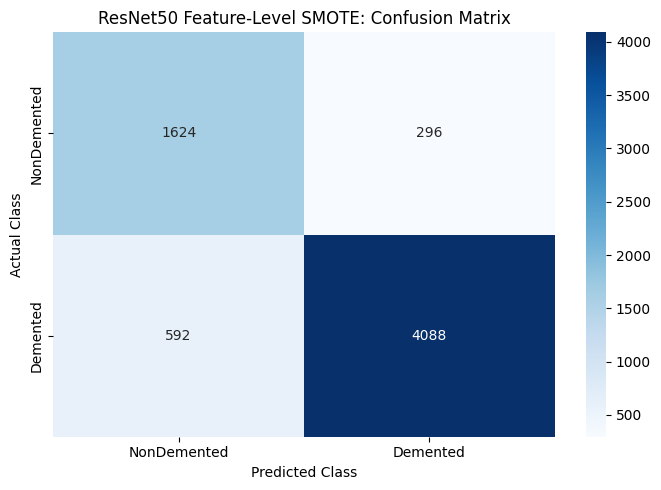

In [23]:
cm = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 Feature-Level SMOTE: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.7329    0.8458    0.7853      1920
    Demented     0.9325    0.8735    0.9020      4680

    accuracy                         0.8655      6600
   macro avg     0.8327    0.8597    0.8437      6600
weighted avg     0.8744    0.8655    0.8681      6600



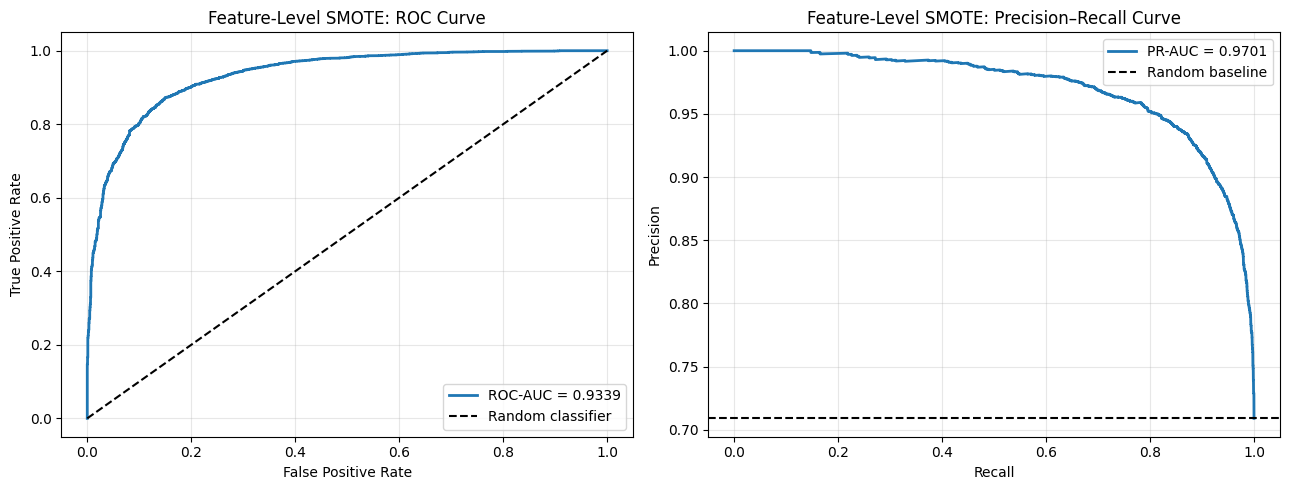

In [25]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(
    true_labels,
    test_probabilities
)

pr_precision, pr_recall, _ = precision_recall_curve(
    true_labels,
    test_probabilities
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}"
)
axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random classifier"
)
axes[0].set_title("Feature-Level SMOTE: ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)
axes[1].axhline(
    true_labels.mean(),
    color="black",
    linestyle="--",
    label="Random baseline"
)
axes[1].set_title("Feature-Level SMOTE: Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Maximum difference from cached predictions: 2.682209e-06
End-to-end prediction consistency check passed.


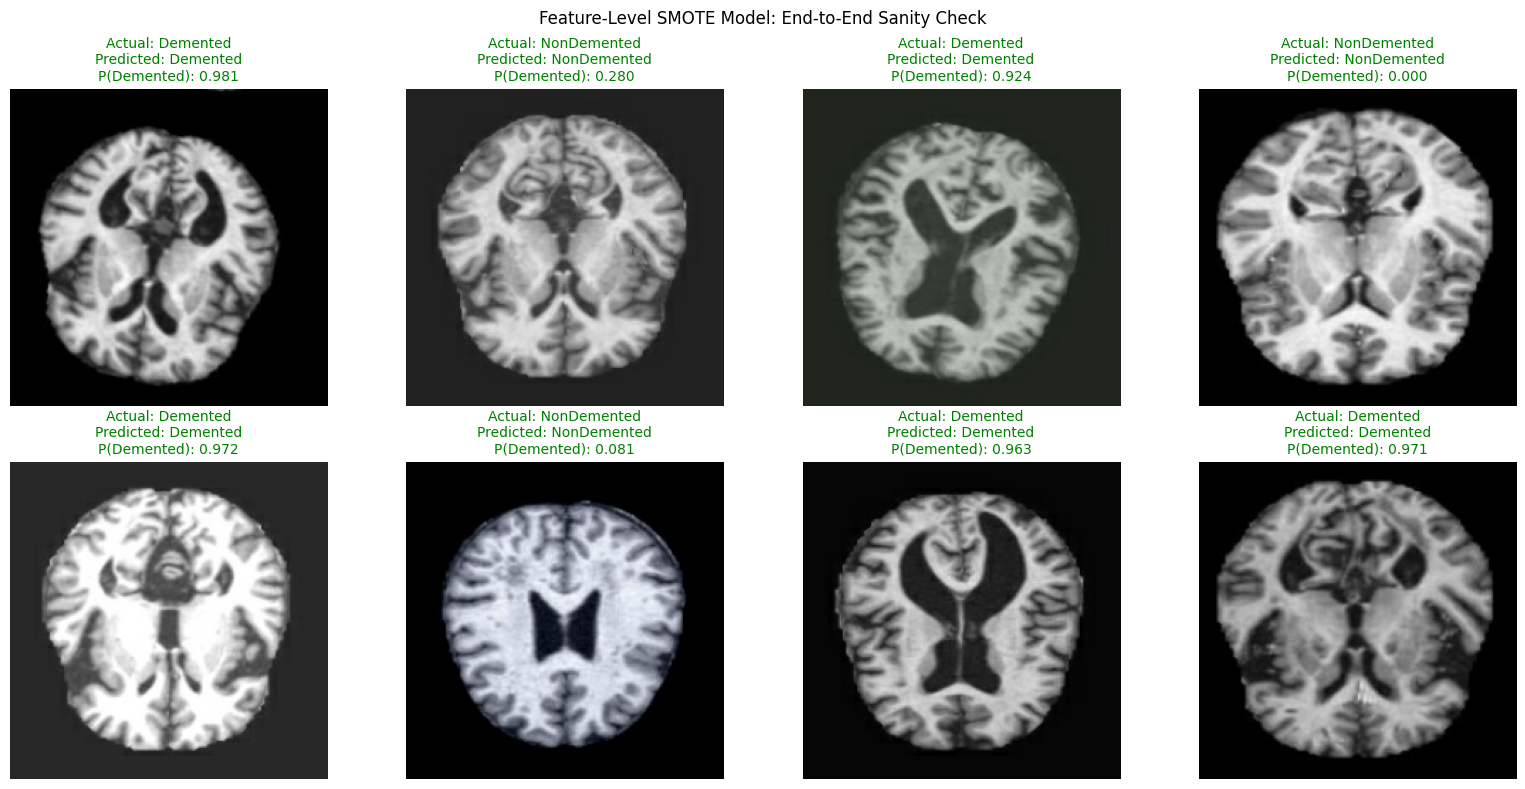

In [26]:
sample_indices = np.linspace(
    0,
    len(test_df) - 1,
    8,
    dtype=int
)

sample_paths = test_df.iloc[
    sample_indices
]["filepath"].tolist()

sample_images = tf.stack([
    load_original_image(tf.constant(path))
    for path in sample_paths
])

# Raw MRI → ResNet50 embeddings
sample_embeddings = feature_extractor.predict(
    sample_images,
    verbose=0
).astype(np.float32)

# Embeddings → training-fitted scaler
sample_embeddings_scaled = feature_scaler.transform(
    sample_embeddings
).astype(np.float32)

# Scaled embeddings → classifier
sample_probabilities = best_classifier.predict(
    sample_embeddings_scaled,
    verbose=0
).ravel()

sample_predictions = (
    sample_probabilities >= 0.5
).astype(int)

cached_probabilities = test_probabilities[
    sample_indices
]

maximum_difference = np.max(
    np.abs(
        sample_probabilities -
        cached_probabilities
    )
)

print(
    "Maximum difference from cached predictions:",
    maximum_difference
)

assert maximum_difference < 1e-3
print("End-to-end prediction consistency check passed.")

plt.figure(figsize=(16, 8))

for plot_number, index in enumerate(
    sample_indices,
    start=1
):
    actual_label = true_labels[index]
    predicted_label = sample_predictions[plot_number - 1]
    probability = sample_probabilities[plot_number - 1]

    actual_name = (
        "Demented" if actual_label == 1
        else "NonDemented"
    )
    predicted_name = (
        "Demented" if predicted_label == 1
        else "NonDemented"
    )

    title_color = (
        "green" if actual_label == predicted_label
        else "red"
    )

    plt.subplot(2, 4, plot_number)
    plt.imshow(
        sample_images[plot_number - 1].numpy().astype(np.uint8)
    )
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"P(Demented): {probability:.3f}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle(
    "Feature-Level SMOTE Model: End-to-End Sanity Check"
)
plt.tight_layout()
plt.show()

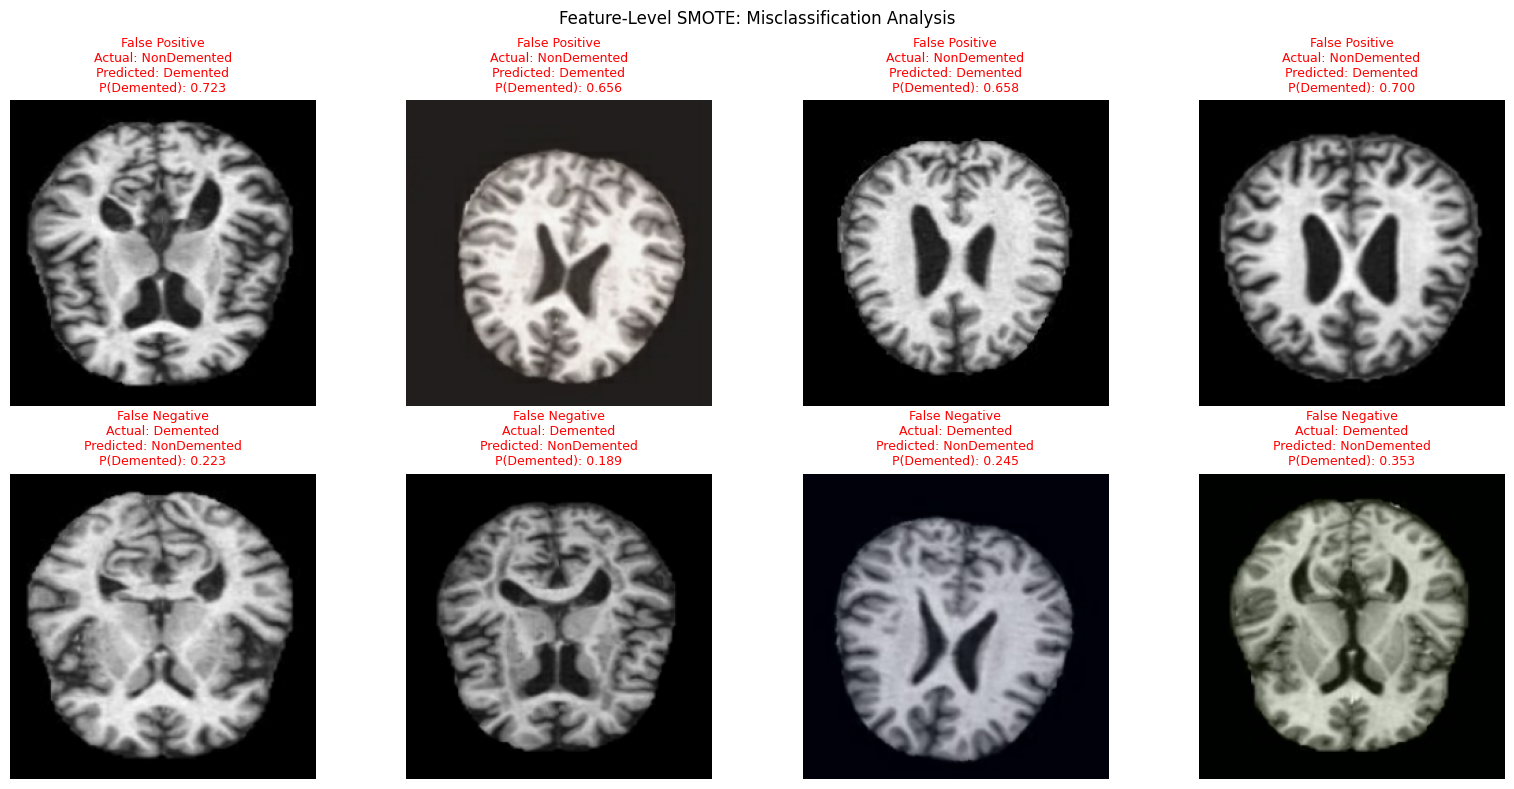

False positives: 296
False negatives: 592


In [27]:
false_positive_indices = np.where(
    (true_labels == 0) &
    (test_predictions == 1)
)[0]

false_negative_indices = np.where(
    (true_labels == 1) &
    (test_predictions == 0)
)[0]

rng = np.random.default_rng(SEED)

selected_fp = rng.choice(
    false_positive_indices,
    size=min(4, len(false_positive_indices)),
    replace=False
)

selected_fn = rng.choice(
    false_negative_indices,
    size=min(4, len(false_negative_indices)),
    replace=False
)

error_indices = np.concatenate([
    selected_fp,
    selected_fn
])

plt.figure(figsize=(16, 8))

for plot_number, index in enumerate(
    error_indices,
    start=1
):
    image = load_original_image(
        tf.constant(test_df.iloc[index]["filepath"])
    )

    actual_name = (
        "Demented" if true_labels[index] == 1
        else "NonDemented"
    )
    predicted_name = (
        "Demented" if test_predictions[index] == 1
        else "NonDemented"
    )

    error_type = (
        "False Positive"
        if true_labels[index] == 0
        else "False Negative"
    )

    plt.subplot(2, 4, plot_number)
    plt.imshow(image.numpy().astype(np.uint8))
    plt.title(
        f"{error_type}\n"
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"P(Demented): {test_probabilities[index]:.3f}",
        color="red",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Feature-Level SMOTE: Misclassification Analysis")
plt.tight_layout()
plt.show()

print("False positives:", len(false_positive_indices))
print("False negatives:", len(false_negative_indices))

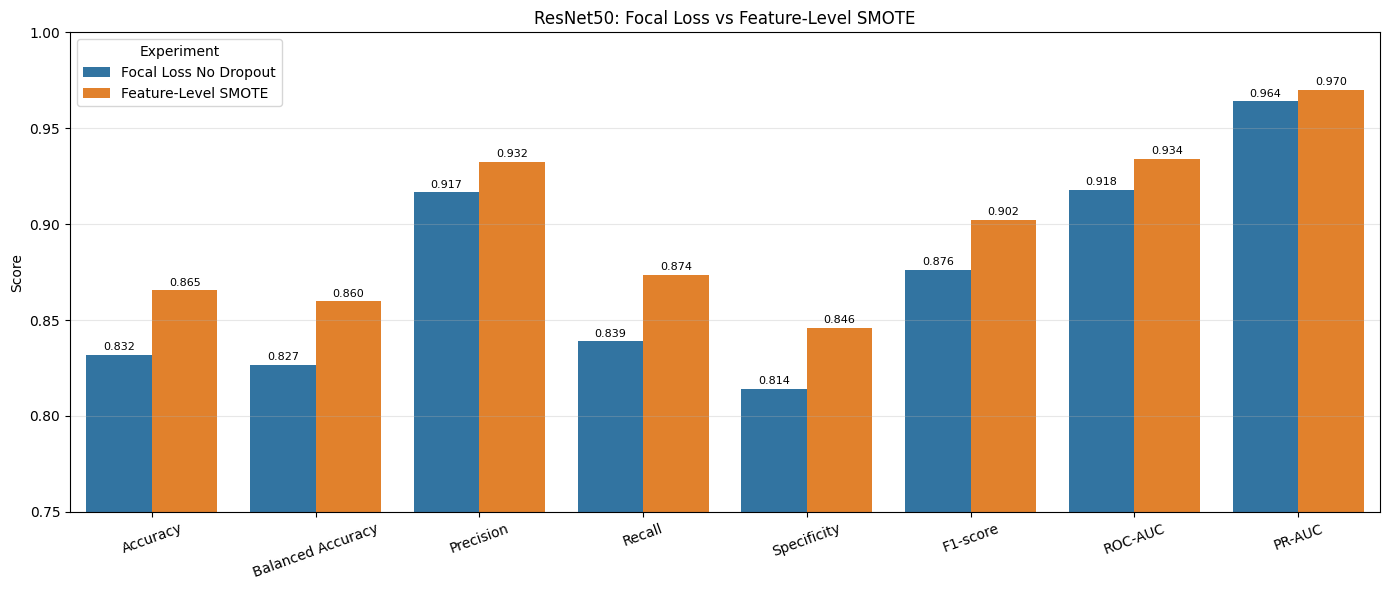

,Metric,Focal Loss No Dropout,Feature-Level SMOTE
0,Accuracy,0.8317,0.8655
1,Balanced Accuracy,0.8265,0.8597
2,Precision,0.9166,0.9325
3,Recall,0.8389,0.8735
4,Specificity,0.8141,0.8458
5,F1-score,0.8760,0.9020
6,ROC-AUC,0.9177,0.9339
7,PR-AUC,0.9640,0.9701


In [28]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy", "Balanced Accuracy", "Precision",
        "Recall", "Specificity", "F1-score",
        "ROC-AUC", "PR-AUC"
    ],
    "Focal Loss No Dropout": [
        0.8317, 0.8265, 0.9166, 0.8389,
        0.8141, 0.8760, 0.9177, 0.9640
    ],
    "Feature-Level SMOTE": [
        accuracy, balanced_accuracy, precision,
        recall, specificity, f1, roc_auc, pr_auc
    ]
})

plot_data = comparison.melt(
    id_vars="Metric",
    var_name="Experiment",
    value_name="Score"
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Experiment"
)

plt.ylim(0.75, 1.0)
plt.title("ResNet50: Focal Loss vs Feature-Level SMOTE")
plt.xlabel("")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

display(comparison.round(4))

In [29]:
import json

results = pd.DataFrame([{
    "Experiment": "ResNet50 Feature-Level SMOTE",
    "SMOTE k-neighbors": 5,
    "Synthetic Embeddings": synthetic_count,
    "Test Loss": test_loss,
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

results.to_csv(
    "/kaggle/working/resnet50_feature_smote_results.csv",
    index=False
)

pd.DataFrame(history.history).to_csv(
    "/kaggle/working/resnet50_feature_smote_history.csv",
    index=False
)

prediction_results = test_df.copy()
prediction_results["probability"] = test_probabilities
prediction_results["prediction"] = test_predictions

prediction_results.to_csv(
    "/kaggle/working/resnet50_feature_smote_predictions.csv",
    index=False
)

comparison.to_csv(
    "/kaggle/working/focal_vs_feature_smote_comparison.csv",
    index=False
)

feature_extractor.save(
    "/kaggle/working/resnet50_feature_extractor.keras"
)

experiment_config = {
    "seed": SEED,
    "image_size": list(IMG_SIZE),
    "embedding_size": 2048,
    "extraction_batch_size": EXTRACTION_BATCH_SIZE,
    "classifier_batch_size": CLASSIFIER_BATCH_SIZE,
    "smote_k_neighbors": 5,
    "smote_sampling_strategy": "auto",
    "classifier_loss": "binary_crossentropy",
    "classification_threshold": 0.5,
    "dropout": False,
    "class_weights": False,
    "focal_loss": False
}

with open(
    "/kaggle/working/resnet50_feature_smote_config.json",
    "w"
) as file:
    json.dump(experiment_config, file, indent=4)

display(results)
print("All feature-level SMOTE files saved.")

,Experiment,SMOTE k-neighbors,Synthetic Embeddings,Test Loss,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,ResNet50 Feature-Level SMOTE,5,12880,0.318685,0.865455,0.859669,0.932482,0.873504,0.845833,0.90203,0.933912,0.970112


All feature-level SMOTE files saved.
